#### Impact of Hypothesis 1 violations on the U-shape of $B^*_\delta$

Hypothesis 1 (ranking) requires every non-error to have a **strictly** higher $\kappa_f$ than every
error, within the stratum $S_n\cap A$ -- equivalently, a ranking AUC of exactly 1. It is only ever
used to prove that $\theta\mapsto B^*_\delta(\theta)$ is U-shaped (Prop. 5), which in turn gives
Algorithm 2 its coverage-maximizing property (Cor. 2). Validity (Prop. 3) needs no hypothesis at all.

Here we dial the AUC from 1 down to 0.5 and measure how far the **conclusion** degrades:

* `n_valleys` -- number of (down, up) turns in the bound path; U-shaped $\iff$ 1
* `interval_rate` -- fraction of *all* sublevel sets $\{\theta: B^*_\delta(\theta)\le r\}$ that are
  intervals; equals 1 iff the path is exactly quasiconvex, and degrades gracefully otherwise
* `completeness_rate` -- fraction of targets where Algorithm 2 returns $\min(\Theta)=\min(S)$
* `empty_rate` -- fraction of targets where $\Theta=\emptyset$ although $S\neq\emptyset$ (the Cor. 2
  bin-alignment gap, independent of Hypothesis 1)

In [1]:
%run -i ../python_scripts/nb_setup.py

GPU Available: False


In [2]:
from scipy.stats import norm, rankdata

METRIC = "standard"
THETA_MIN, THETA_MAX = 0.5, 1
AUCS = [1.0, 0.99, 0.95, 0.90, 0.85, 0.80, 0.70, 0.60, 0.50]
SIZES = [2000, 8000, 32000]
NUM_SEEDS = 15
TARGETS = np.linspace(0.01, 0.5, 200)

Simulator: the ranking AUC is set exactly, and errors are drawn independently of `y_true`, so the same AUC holds on every stratum (`FPR`, `FNR`, `PPV`, ...) at once.

In [ ]:
def simulate(n, auc, err_rate=0.12, prevalence=0.35, seed=0):
    rng = np.random.default_rng(seed)
    y_true = rng.binomial(1, prevalence, n)
    err = rng.random(n) < err_rate
    if auc >= 1:
        kappa = np.where(err, rng.uniform(0.5, 0.7, n), rng.uniform(0.7, 1.0, n))
    else:
        mu = np.sqrt(2) * norm.ppf(auc)  # AUC = Phi(mu / sqrt(2))
        kappa = 0.5 + 0.5 * norm.cdf(rng.normal(np.where(err, 0.0, mu), 1.0))
    return pd.DataFrame(
        {"kappa": kappa, "y_true": y_true, "y_pred": np.where(err, 1 - y_true, y_true)}
    )

In [4]:
def errs_mask(samples, loss="standard"):
    if loss == "standard":
        return samples.y_pred != samples.y_true
    elif loss == "FP":
        return (samples.y_pred == 1) & (samples.y_true == 0)
    else:
        return (samples.y_pred == 0) & (samples.y_true == 1)


def ranking_auc(Sn, metric):
    st = stratify(Sn, metric)
    err = errs_mask(st, METRIC_LOSS[metric]).values
    kappa = st.kappa.values
    n_err, n_ok = int(err.sum()), int((~err).sum())
    if n_err == 0 or n_ok == 0:
        return np.nan, True
    ranks = rankdata(kappa)
    auc = (ranks[~err].sum() - n_ok * (n_ok + 1) / 2) / (n_ok * n_err)
    return auc, bool(kappa[err].max() < kappa[~err].min())

In [5]:
df = simulate(20000, 0.85, seed=0)
for m in ["standard", "FPR", "FNR", "PPV"]:
    auc, holds = ranking_auc(df, m)
    print(f"{m:9s} AUC={auc:.3f}  H1 holds={holds}")

standard  AUC=0.848  H1 holds=False
FPR       AUC=0.846  H1 holds=False
FNR       AUC=0.851  H1 holds=False
PPV       AUC=0.846  H1 holds=False


Diagnostics on the bound path. `bound_path` drops the vacuous tail and flips the sign for the lower-bounded metrics, so smaller is always better.

In [ ]:
def bound_path(
    Sn, metric, delta=DELTA, theta_min=THETA_MIN, theta_max=THETA_MAX, k=K, J=J
):
    path = sgp_multistart_search(
        delta, None, Sn, metric, theta_min=theta_min, theta_max=theta_max, k=k, J=J
    )
    keep = [rec for rec in path if not rec["vacuous"]]
    b = np.array([rec["bound"] for rec in keep], dtype=float)
    return keep, (-b if metric in LOWER_BOUNDED else b)


def shape_stats(b, tol=0.0):
    d = np.diff(b)
    sign = np.sign(np.where(np.abs(d) <= tol, 0, d))
    sign = sign[sign != 0]
    turns = int(np.sum((sign[:-1] < 0) & (sign[1:] > 0))) if len(sign) > 1 else 0
    i = int(b.argmin())
    down, up = np.diff(b[: i + 1]), np.diff(b[i:])
    return {
        "u_shaped": turns <= 1,
        "n_valleys": max(turns, 1),
        "max_violation": float(max(down.max(initial=0.0), -up.min(initial=0.0))),
        "argmin_frac": i / max(len(b) - 1, 1),
    }


def interval_rate(b):
    ok = [
        len(np.where(b <= lvl)[0]) == np.ptp(np.where(b <= lvl)[0]) + 1
        for lvl in np.unique(b)
    ]
    return float(np.mean(ok))


def target_stats(keep, b, metric, targets):
    bins = np.array([rec["bin"] for rec in keep])
    complete, empty = [], []
    for r in targets:
        acc = np.where(b <= (-r if metric in LOWER_BOUNDED else r))[0]
        if len(acc) == 0:
            continue
        Theta = []
        for j in np.unique(bins):
            idx = np.where(bins == j)[0]
            last = None
            for t in idx[::-1]:
                if t not in acc:
                    break
                last = t
            if last is not None:
                Theta.append(last)
        empty.append(len(Theta) == 0)
        complete.append(bool(Theta) and min(Theta) == acc.min())
    if not complete:
        return {}
    return {
        "empty_rate": np.mean(empty),
        "completeness_rate": np.mean(complete),
        "n_targets_reached": len(complete),
    }

#### Sweep

In [ ]:
rows = []
for n in SIZES:
    for auc in tqdm(AUCS, desc=f"n={n}"):
        for seed in range(NUM_SEEDS):
            sim = simulate(n, auc, seed=seed)
            keep, b = bound_path(sim, METRIC)
            if len(b) < 3:
                continue
            auc_emp, holds = ranking_auc(sim, METRIC)
            rows.append(
                {
                    "auc": auc,
                    "n": n,
                    "seed": seed,
                    "auc_emp": auc_emp,
                    "h1_holds": holds,
                    "interval_rate": interval_rate(b),
                    **shape_stats(b),
                    **target_stats(keep, b, METRIC, TARGETS),
                }
            )
res = pd.DataFrame(rows)
res.head()

n=32000: 100%|██████████| 9/9 [01:43<00:00, 11.54s/it]


,auc,n,seed,auc_emp,h1_holds,interval_rate,u_shaped,n_valleys,max_violation,argmin_frac,empty_rate,completeness_rate,n_targets_reached
0,1.0,2000,0,1.0,True,1.0,True,1,0.0,0.40404,0.0,1.0,200
1,1.0,2000,1,1.0,True,1.0,True,1,0.0,0.40404,0.0,1.0,200
2,1.0,2000,2,1.0,True,1.0,True,1,0.0,0.40404,0.0,1.0,200
3,1.0,2000,3,1.0,True,1.0,True,1,0.0,0.40404,0.0,1.0,200
4,1.0,2000,4,1.0,True,1.0,True,1,0.0,0.40404,0.0,1.0,200


In [ ]:
agg = (
    res.groupby(["n", "auc"])
    .agg(
        auc_emp=("auc_emp", "mean"),
        h1=("h1_holds", "mean"),
        u_shaped=("u_shaped", "mean"),
        valleys=("n_valleys", "mean"),
        max_viol=("max_violation", "mean"),
        interval=("interval_rate", "mean"),
        empty=("empty_rate", "mean"),
        complete=("completeness_rate", "mean"),
    )
    .round(3)
)
display(agg)

auc_emp   h1  u_shaped  valleys  max_viol  interval  empty  \
n     auc                                                                
2000  0.50    0.503  0.0     0.000   21.867     0.015     0.225  0.010   
      0.60    0.604  0.0     0.000   23.133     0.013     0.193  0.013   
      0.70    0.704  0.0     0.000   18.333     0.007     0.545  0.021   
      0.80    0.803  0.0     0.000   12.667     0.003     0.760  0.018   
      0.85    0.852  0.0     0.000    9.667     0.002     0.842  0.011   
      0.90    0.902  0.0     0.000    7.333     0.001     0.905  0.003   
      0.95    0.951  0.0     0.000    5.000     0.000     0.943  0.001   
      0.99    0.990  0.0     0.400    2.000     0.000     0.978  0.000   
      1.00    1.000  1.0     1.000    1.000     0.000     1.000  0.000   
8000  0.50    0.503  0.0     0.000   23.200     0.008     0.240  0.002   
      0.60    0.603  0.0     0.000   19.000     0.006     0.485  0.014   
      0.70    0.703  0.0     0.000    8.000     0.003     0.854  0.008   
      0.80    0.803  0.0     0.133    2.867     0.001     0.964  0.001   
      0.85    0.853  0.0     0.667    1.400     0.000     0.987  0.000   
      0.90    0.902  0.0     0.933    1.067     0.000     0.996  0.000   
      0.95    0.952  0.0     1.000    1.000     0.000     0.999  0.000   
      0.99    0.991  0.0     1.000    1.000     0.000     1.000  0.000   
      1.00    1.000  1.0     1.000    1.000     0.000     1.000  0.000   
32000 0.50    0.499  0.0     0.000   22.867     0.005     0.226  0.002   
      0.60    0.599  0.0     0.000    8.733     0.002     0.844  0.015   
      0.70    0.699  0.0     0.667    1.667     0.000     0.987  0.002   
      0.80    0.799  0.0     1.000    1.000     0.000     1.000  0.000   
      0.85    0.849  0.0     1.000    1.000     0.000     1.000  0.000   
      0.90    0.899  0.0     1.000    1.000     0.000     1.000  0.000   
      0.95    0.950  0.0     1.000    1.000     0.000     1.000  0.000   
      0.99    0.990  0.0     1.000    1.000     0.000     1.000  0.000   
      1.00    1.000  1.0     1.000    1.000     0.000     1.000  0.000   

            complete  
n     auc             
2000  0.50     0.983  
      0.60     0.968  
      0.70     0.961  
      0.80     0.965  
      0.85     0.982  
      0.90     0.990  
      0.95     0.997  
      0.99     1.000  
      1.00     1.000  
8000  0.50     0.995  
      0.60     0.974  
      0.70     0.981  
      0.80     0.997  
      0.85     0.999  
      0.90     1.000  
      0.95     1.000  
      0.99     1.000  
      1.00     1.000  
32000 0.50     0.997  
      0.60     0.982  
      0.70     0.997  
      0.80     1.000  
      0.85     1.000  
      0.90     1.000  
      0.95     1.000  
      0.99     1.000  
      1.00     1.000

#### The bound path as the AUC degrades

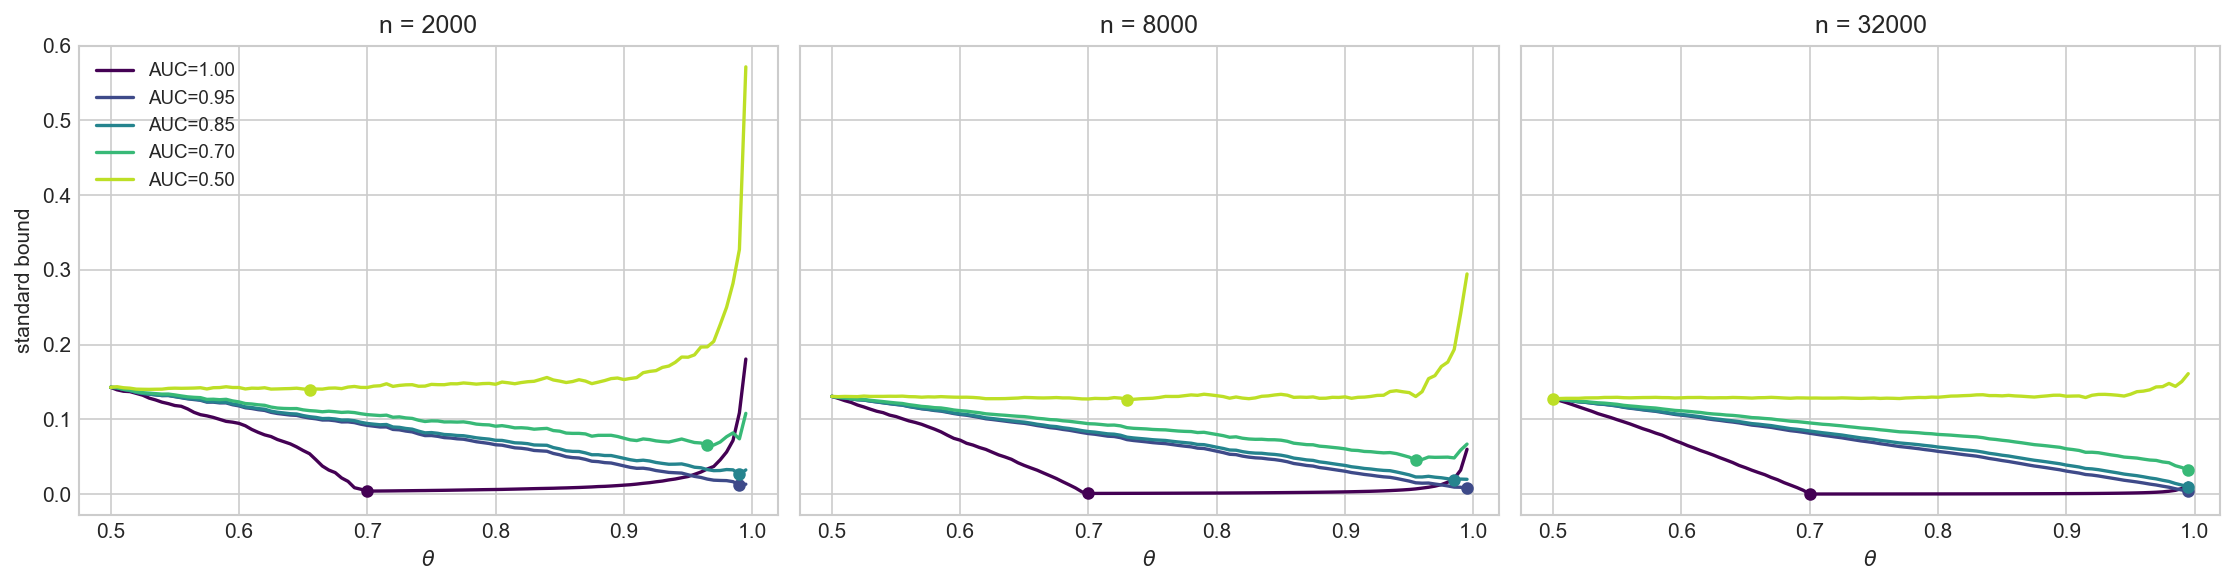

In [ ]:
shown = [1.0, 0.95, 0.85, 0.70, 0.50]
with plt.style.context("seaborn-v0_8-whitegrid"):
    fig, axes = plt.subplots(1, len(SIZES), figsize=(5 * len(SIZES), 4), sharey=True)
    colors = plt.get_cmap("viridis")(np.linspace(0, 0.9, len(shown)))
    for ax, n in zip(np.atleast_1d(axes), SIZES):
        for c, auc in zip(colors, shown):
            keep, b = bound_path(simulate(n, auc, seed=0), METRIC)
            ax.plot(
                [r["theta_star"] for r in keep],
                b,
                color=c,
                lw=1.6,
                label=f"AUC={auc:.2f}",
            )
            ax.plot(keep[int(b.argmin())]["theta_star"], b.min(), "o", color=c, ms=5)
        ax.set_title(f"n = {n}")
        ax.set_xlabel(r"$\theta$")
    np.atleast_1d(axes)[0].set_ylabel(f"{METRIC} bound")
    np.atleast_1d(axes)[0].legend(fontsize=9)
    plt.tight_layout()
    plt.show()

#### Degradation of the conclusion

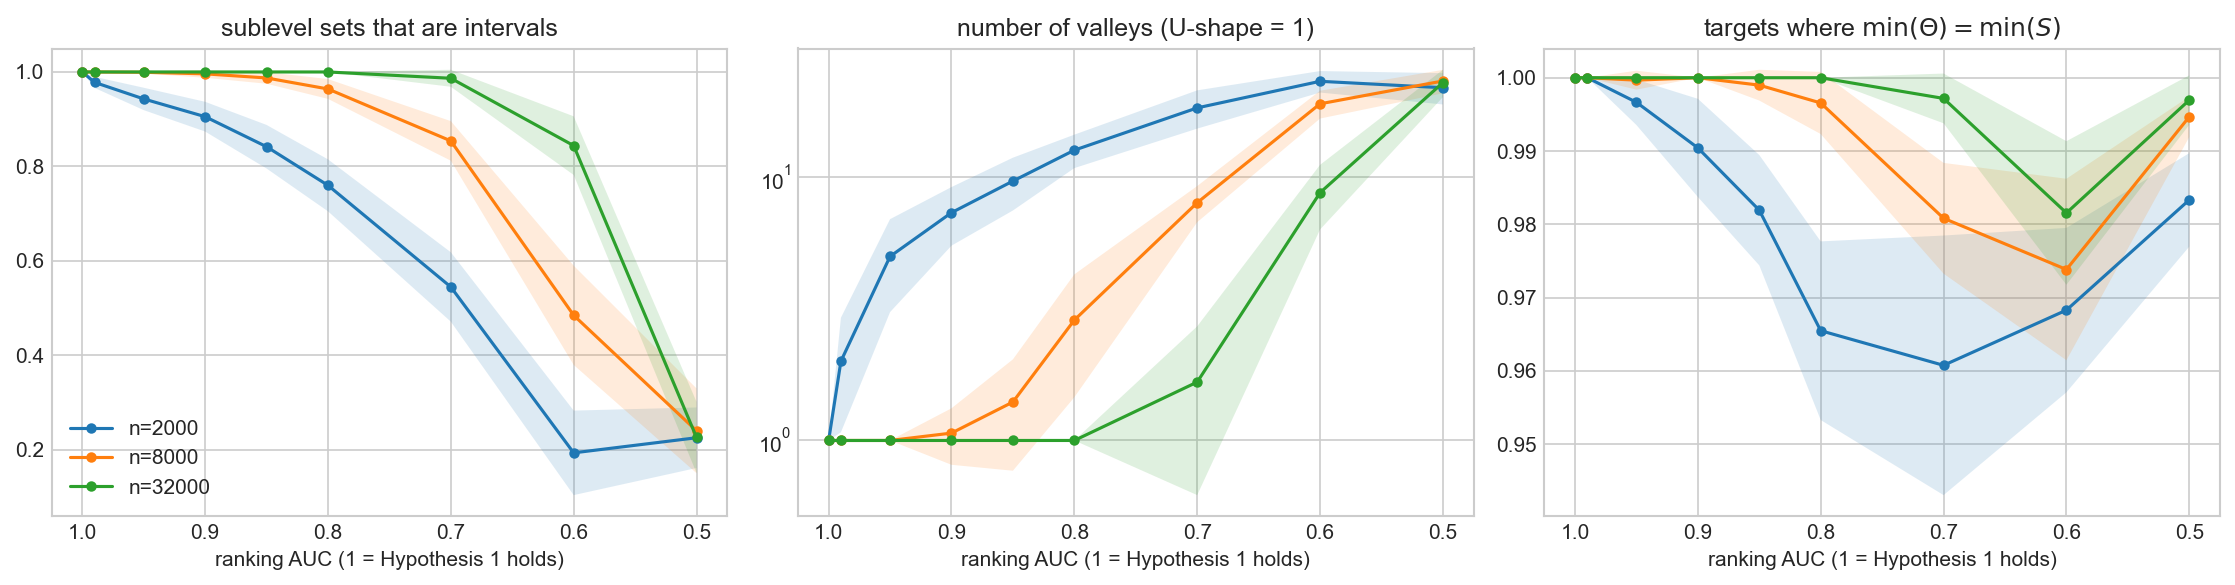

In [ ]:
panels = [
    ("interval_rate", "sublevel sets that are intervals"),
    ("n_valleys", "number of valleys (U-shape = 1)"),
    ("completeness_rate", r"targets where $\min(\Theta)=\min(S)$"),
]
with plt.style.context("seaborn-v0_8-whitegrid"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (col, title) in zip(axes, panels):
        for n, g in res.groupby("n"):
            m = g.groupby("auc")[col].mean()
            sd = g.groupby("auc")[col].std()
            ax.plot(m.index, m.values, marker="o", ms=4, label=f"n={n}")
            ax.fill_between(m.index, m - sd, m + sd, alpha=0.15)
        ax.set_xlabel("ranking AUC (1 = Hypothesis 1 holds)")
        ax.set_title(title)
        ax.invert_xaxis()
        if col == "n_valleys":
            ax.set_yscale("log")
    axes[0].legend()
    plt.tight_layout()
    plt.show()

#### Reading the result

Hypothesis 1 flips to `False` as soon as the AUC leaves 1, but the conclusion it is used to prove
degrades **gradually and much later**, and the sample size buys most of the slack: the bound is
driven by the discreteness of the error count, so a larger $S_n$ smooths the path and keeps it
U-shaped far below AUC = 1.

What survives throughout is `completeness_rate`. Even where the path is visibly ragged, the wobble
is orders of magnitude smaller than the spacing between targets, so the accepted set stays an
interval around the target levels one actually uses, and Algorithm 2 keeps returning the
coverage-maximizing threshold. `empty_rate` moves independently of the AUC, as expected -- it
reflects bin alignment (Cor. 2), not the ranking.